## Deo 1: ucitavanje podataka

Sirovi skup `K8.data` se nalazi unutar arhive `data/raw/p53+mutants.zip` (ugnežden u `p53_old_2010.zip`). Svaki red ima 5408 numeričkih atributa, zatim ciljnu klasu, pa prateći zarez koji pravi praznu kolonu na kraju. Nedostajuće vrednosti su označene znakom `?`.

In [86]:
import io
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

RAW_DIR = Path("data/raw")
ZIP_PATH = RAW_DIR / "p53+mutants.zip"
DATA_PATH = RAW_DIR / "K8.data"
N_FEATURES = 5408

In [87]:
# Extract K8.data from the nested archive on first run only.
if not DATA_PATH.exists():
    with zipfile.ZipFile(ZIP_PATH) as outer:
        old = zipfile.ZipFile(io.BytesIO(outer.read("p53_old_2010.zip")))
        with old.open("p53_old_2010/K8.data") as src, open(DATA_PATH, "wb") as dst:
            for chunk in iter(lambda: src.read(8 * 1024 * 1024), b""):
                dst.write(chunk)
    print("Extracted:", DATA_PATH)
else:
    print("Already extracted:", DATA_PATH)

Already extracted: data/raw/K8.data


In [88]:
# Features as float32 to keep memory low, class as string, drop trailing empty column.
dtypes = {i: "float32" for i in range(N_FEATURES)}
dtypes[N_FEATURES] = "object"
dtypes[N_FEATURES + 1] = "object"

df = pd.read_csv(DATA_PATH, header=None, na_values="?", dtype=dtypes)
df = df.drop(columns=[N_FEATURES + 1])

X = df.iloc[:, :N_FEATURES]
y = df.iloc[:, N_FEATURES].rename("class")
del df

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (16772, 5408)
y shape: (16772,)


In [89]:
# Class distribution and a quick look at missing values.
print("Class distribution:")
print(y.value_counts())
print("\nActive ratio: {:.2%}".format((y == "active").mean()))

missing_per_row = X.isna().sum(axis=1)
print("\nRows with missing values:", int((missing_per_row > 0).sum()))
print("Total missing cells:", int(X.isna().sum().sum()))

Class distribution:
class
inactive    16629
active        143
Name: count, dtype: int64

Active ratio: 0.85%

Rows with missing values: 180
Total missing cells: 901854


## Deo 2: EDA i vizuelizacija

U ovom delu istražujemo podatke pre modelovanja: raspodelu klasa, nedostajuće vrednosti i osnovne statistike atributa. Zatim projektujemo 5408-dimenzioni prostor u 2D i 3D pomoću PCA i t-SNE, da vidimo da li se klase razdvajaju. Svi grafici se snimaju u `figures/`.

In [90]:
import matplotlib.pyplot as plt

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110

### Raspodela klasa

Skup je jako nebalansiran. To je ključno jer model koji uvek predviđa `inactive` ima oko 99% tačnosti, a potpuno je beskoristan. Zato kasnije koristimo metrike kao što su F1 i recall na klasi `active`, a ne tačnost.

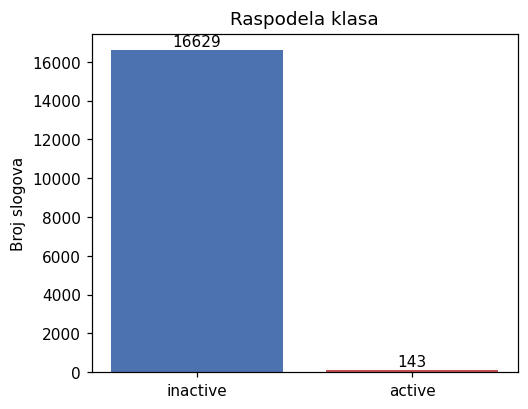

In [91]:
counts = y.value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(counts.index, counts.values, color=["#4c72b0", "#c44e52"])
for i, v in enumerate(counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
ax.set_ylabel("Broj slogova")
ax.set_title("Raspodela klasa")
fig.savefig(FIG_DIR / "class_distribution.png", bbox_inches="tight")
plt.show()

### Nedostajuce vrednosti

Nedostajuće vrednosti se javljaju u 180 slogova. Od toga je 57 potpuno praznih (svih 5408 atributa nedostaje), a 123 sloga nemaju ceo 2D blok atributa (prvih 4826). Svi takvi slogovi pripadaju klasi `inactive`, pa ih u pretprocesiranju možemo izbaciti bez gubitka ijednog `active` sloga.

Rows with missing values: 180
Fully empty: 57
Missing whole 2D block (4826): 123


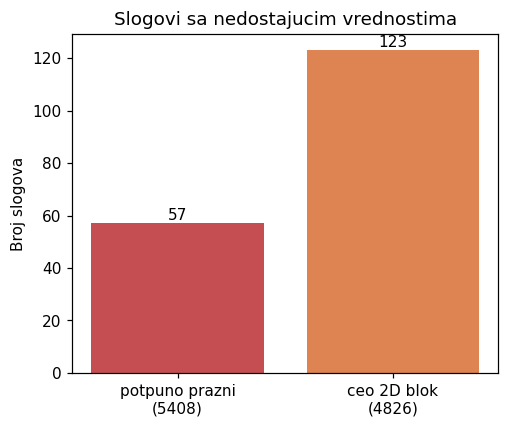

In [92]:
affected = missing_per_row[missing_per_row > 0]
fully = int((affected == N_FEATURES).sum())
block_2d = int((affected == 4826).sum())

print("Rows with missing values:", len(affected))
print("Fully empty:", fully)
print("Missing whole 2D block (4826):", block_2d)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["potpuno prazni\n(5408)", "ceo 2D blok\n(4826)"], [fully, block_2d],
       color=["#c44e52", "#dd8452"])
for i, v in enumerate([fully, block_2d]):
    ax.text(i, v, str(v), ha="center", va="bottom")
ax.set_ylabel("Broj slogova")
ax.set_title("Slogovi sa nedostajucim vrednostima")
fig.savefig(FIG_DIR / "missing_values.png", bbox_inches="tight")
plt.show()

### Statistike atributa

Atributi su realne vrednosti različitih opsega, pa ćemo ih kasnije standardizovati. Ovde gledamo raspodelu srednjih vrednosti i standardnih devijacija po atributu, samo nad potpunim slogovima, da steknemo osećaj o podacima.

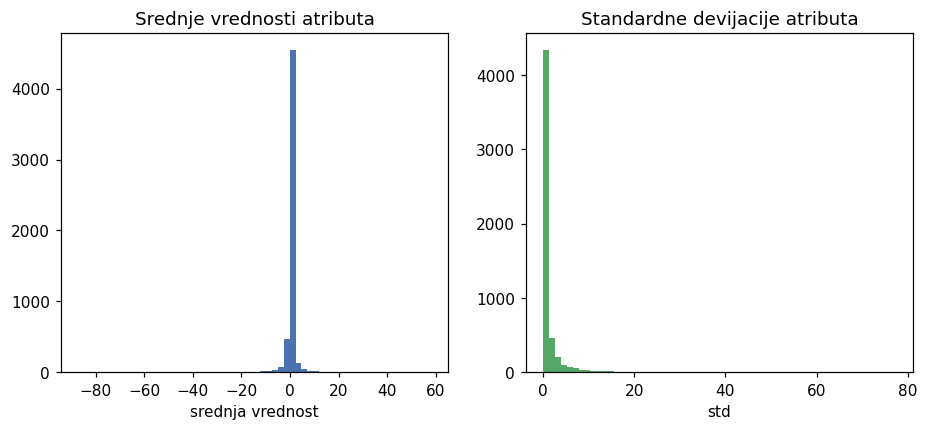

In [93]:
X_ok = X[X.notna().all(axis=1)]
feat_mean = X_ok.mean()
feat_std = X_ok.std()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(feat_mean, bins=60, color="#4c72b0")
axes[0].set_title("Srednje vrednosti atributa")
axes[0].set_xlabel("srednja vrednost")
axes[1].hist(feat_std, bins=60, color="#55a868")
axes[1].set_title("Standardne devijacije atributa")
axes[1].set_xlabel("std")
fig.savefig(FIG_DIR / "feature_stats.png", bbox_inches="tight")
plt.show()

### Projekcija u 2D i 3D

Da bismo videli podatke, sabijamo 5408 atributa na malo dimenzija. Prvo izbacujemo slogove sa nedostajućim vrednostima i standardizujemo atribute (PCA je osetljiv na razmeru). PCA daje linearnu projekciju u 2D i 3D, a t-SNE nelinearnu projekciju u 2D na uzorku (jer je spor). Klasu `active` crtamo preko `inactive` da bi bila vidljiva.

In [94]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Keep only complete rows (all missing rows are inactive), then standardize.
complete = X.notna().all(axis=1)
X_clean = X[complete]
y_clean = y[complete].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean).astype("float32")

print("Rows for visualization:", X_scaled.shape)
print("Active count:", int((y_clean == "active").sum()))

Rows for visualization: (16592, 5408)
Active count: 143


Explained variance (PC1-3): [0.077 0.072 0.049]


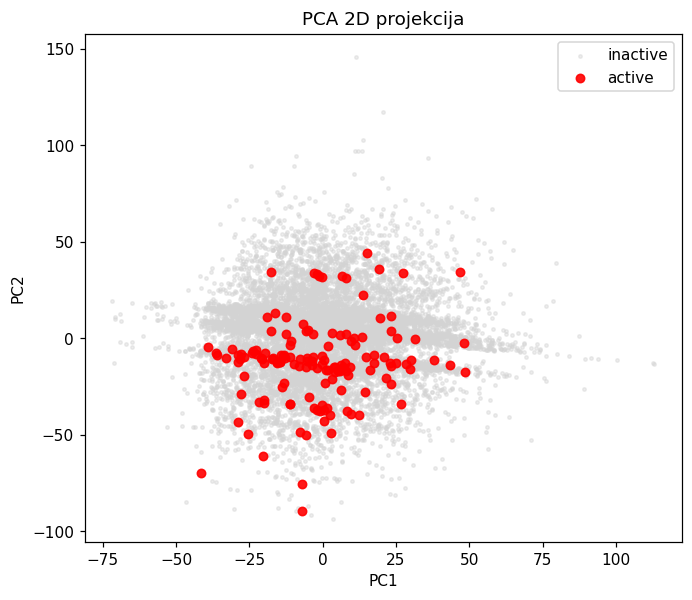

In [95]:
pca = PCA(n_components=3, random_state=0)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance (PC1-3):", pca.explained_variance_ratio_[:3].round(3))

# Split points by class so each gets its own color.
pca_active = X_pca[y_clean == "active"]
pca_inactive = X_pca[y_clean == "inactive"]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pca_inactive[:, 0], pca_inactive[:, 1], s=5, c="lightgray", alpha=0.4, label="inactive")
ax.scatter(pca_active[:, 0], pca_active[:, 1], s=30, c="red", alpha=0.9, label="active")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA 2D projekcija")
ax.legend()
fig.savefig(FIG_DIR / "pca_2d.png", bbox_inches="tight")
plt.show()

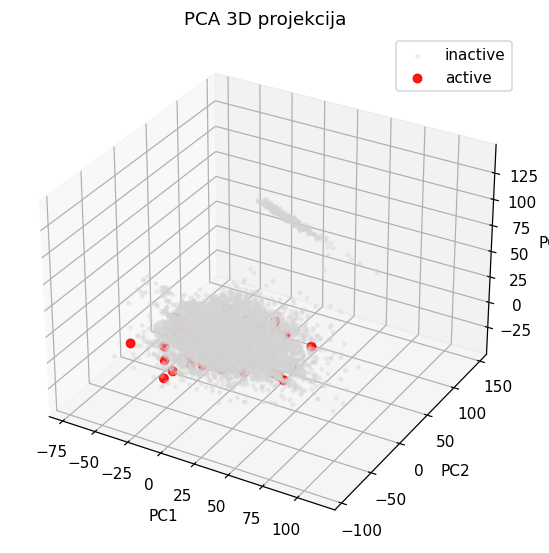

In [96]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(pca_inactive[:, 0], pca_inactive[:, 1], pca_inactive[:, 2],
           s=5, c="lightgray", alpha=0.3, label="inactive")
ax.scatter(pca_active[:, 0], pca_active[:, 1], pca_active[:, 2],
           s=30, c="red", alpha=0.9, label="active")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA 3D projekcija")
ax.legend()
fig.savefig(FIG_DIR / "pca_3d.png", bbox_inches="tight")
plt.show()

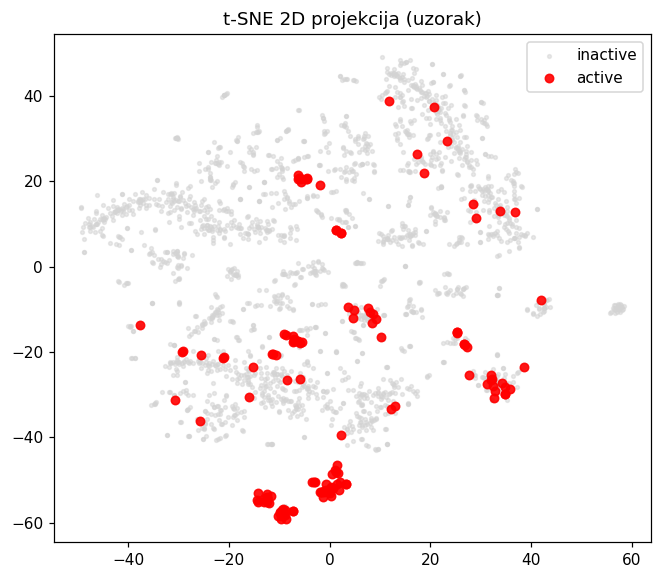

In [97]:
from sklearn.manifold import TSNE

# t-SNE is slow, so take all active rows and 2000 random inactive rows.
rng = np.random.RandomState(0)
active_pos = np.where(y_clean == "active")[0]
inactive_pos = np.where(y_clean == "inactive")[0]
inactive_pick = rng.choice(inactive_pos, 2000, replace=False)
sample = np.concatenate([active_pos, inactive_pick])

X_sample = X_scaled[sample]
y_sample = y_clean[sample]

# Pre-reduce to 50 dimensions with PCA first (faster), then t-SNE to 2D.
X_sample_50 = PCA(n_components=50, random_state=0).fit_transform(X_sample)
X_tsne = TSNE(n_components=2, random_state=0, init="pca", perplexity=30).fit_transform(X_sample_50)

tsne_active = X_tsne[y_sample == "active"]
tsne_inactive = X_tsne[y_sample == "inactive"]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(tsne_inactive[:, 0], tsne_inactive[:, 1], s=6, c="lightgray", alpha=0.5, label="inactive")
ax.scatter(tsne_active[:, 0], tsne_active[:, 1], s=30, c="red", alpha=0.9, label="active")
ax.set_title("t-SNE 2D projekcija (uzorak)")
ax.legend()
fig.savefig(FIG_DIR / "tsne_2d.png", bbox_inches="tight")
plt.show()

## Deo 3: pretprocesiranje

Pre modelovanja pripremamo podatke u četiri koraka:

1. Izbacujemo slogove sa nedostajućim vrednostima (svih 180 su `inactive`, pa ne gubimo nijedan `active`).
2. Ciljnu kolonu kodiramo u brojeve: `active` postaje 1 (klasa koja nas zanima), `inactive` postaje 0.
3. Delimo podatke na trening i test skup (80:20), stratifikovano da odnos klasa ostane isti u oba.
4. Standardizujemo atribute, ali skaler učimo samo na trening skupu da ne bismo preneli informacije iz testa u trening.

Na kraju snimamo pripremljene podatke u `data/processed/`, a skaler u `models/`, da ih kasniji delovi učitaju direktno.

In [98]:
from sklearn.model_selection import train_test_split

# Drop rows with any missing value (we saw all of them are inactive).
complete = X.notna().all(axis=1)
X_full = X[complete].to_numpy(dtype="float32")
y_text = y[complete].values

# Encode target: active is 1 (the class we care about), inactive is 0.
y_full = (y_text == "active").astype("int64")

print("Rows after cleaning:", X_full.shape[0])
print("Active:", int(y_full.sum()), "Inactive:", int((y_full == 0).sum()))

Rows after cleaning: 16592
Active: 143 Inactive: 16449


In [99]:
# Stratified split keeps the same active ratio in train and test.
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=0
)

print("Train rows:", X_train.shape[0], "active:", int(y_train.sum()))
print("Test rows:", X_test.shape[0], "active:", int(y_test.sum()))

Train rows: 13273 active: 114
Test rows: 3319 active: 29


In [100]:
# Fit the scaler on train only, then apply it to both sets.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype("float32")
X_test = scaler.transform(X_test).astype("float32")

print("Scaled train:", X_train.shape)
print("Scaled test:", X_test.shape)

Scaled train: (13273, 5408)
Scaled test: (3319, 5408)


In [101]:
import joblib

PROC_DIR = Path("data/processed")
PROC_DIR.mkdir(exist_ok=True)
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

# Save the split, scaled data and the scaler so later parts can load them.
np.savez_compressed(PROC_DIR / "train_test.npz",
                    X_train=X_train, X_test=X_test,
                    y_train=y_train, y_test=y_test)
joblib.dump(scaler, MODEL_DIR / "scaler.joblib")

print("Saved processed data to:", PROC_DIR / "train_test.npz")

Saved processed data to: data/processed/train_test.npz


## Deo 4: redukcija atributa

Skup ima 5408 atributa, što je mnogo i usporava modele. Zato pravimo tri skupa atributa koja ćemo u sledećem delu porediti:

1. **Svi atributi** - svih 5408, bez redukcije.
2. **PCA (100 komponenti)** - PCA pravi nove ose duž kojih podaci najviše variraju i zadržavamo prvih 100. Tako sažimamo informaciju u mnogo manje dimenzija.
3. **Selekcija (300 atributa)** - biramo 300 originalnih atributa koji su najjače povezani sa klasom (ANOVA F-test).

I PCA i selekciju učimo samo na trening skupu, pa ih primenjujemo na test, isto kao kod skaliranja. Podatke učitavamo iz `data/processed/`, pa ovaj deo radi i bez ponovnog učitavanja sirovog skupa.

In [102]:
import numpy as np
from pathlib import Path

# Load the preprocessed train/test data saved in Deo 3.
data = np.load(Path("data/processed/train_test.npz"))
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (13273, 5408) Test: (3319, 5408)


In [103]:
from sklearn.decomposition import PCA

# PCA learned on train, keeping the first 100 components.
pca = PCA(n_components=100, random_state=0)
X_train_pca = pca.fit_transform(X_train).astype("float32")
X_test_pca = pca.transform(X_test).astype("float32")

print("PCA shape:", X_train_pca.shape)
print("Variance kept:", round(float(pca.explained_variance_ratio_.sum()), 3))

PCA shape: (13273, 100)
Variance kept: 0.648


In [104]:
from sklearn.feature_selection import SelectKBest, f_classif

# Pick the 300 features most related to the class, using an ANOVA F-test on train.
selector = SelectKBest(f_classif, k=300)
X_train_sel = selector.fit_transform(X_train, y_train).astype("float32")
X_test_sel = selector.transform(X_test).astype("float32")

print("Selection shape:", X_train_sel.shape)

Selection shape: (13273, 300)


In [105]:
# Three feature sets to compare in the next part.
feature_sets = {
    "svi atributi": (X_train, X_test),
    "PCA 100": (X_train_pca, X_test_pca),
    "selekcija 300": (X_train_sel, X_test_sel),
}

for name, (tr, te) in feature_sets.items():
    print(name, "-> train", tr.shape, "test", te.shape)

svi atributi -> train (13273, 5408) test (3319, 5408)
PCA 100 -> train (13273, 100) test (3319, 100)
selekcija 300 -> train (13273, 300) test (3319, 300)


## Deo 5: treniranje modela

Treniramo 6 klasifikacionih algoritama, svaki na sva tri skupa atributa iz Dela 4 (ukupno 18 modela), pa ih u sledećem delu poredimo.

Algoritmi:
- **Logistička regresija** - linearni model, jednostavan i brz.
- **Stablo odlučivanja** - pravila tipa "ako-onda", lako se tumači.
- **Random Forest** - kombinuje glasove mnogo stabala, obično tačan.
- **Linearni SVM** - traži granicu koja najbolje razdvaja klase (treniran SGD algoritmom radi brzine na mnogo atributa).
- **KNN** - klasifikuje na osnovu najbližih suseda.
- **Naivni Bayes** - verovatnosni model.

Pošto je skup jako nebalansiran, kod modela koji to podržavaju koristimo `class_weight="balanced"`, što daje veći značaj retkoj klasi `active`. KNN i Naivni Bayes nemaju tu opciju, pa očekujemo da slabije hvataju `active`.

Za svaki model računamo više metrika: accuracy, balanced accuracy, preciznost, recall, F1, ROC-AUC i PR-AUC. Naglasak je na recall i F1 za klasu `active`, jer accuracy ovde obmanjuje (model koji uvek kaže `inactive` ima ~99%). Svaki istrenirani model snimamo u `models/`, a sve metrike u `results/metrics.csv`.

In [106]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# class_weight="balanced" makes a model care more about the rare active class.
# The linear SVM is trained with SGD, which converges fast on many features.
# KNN and Naive Bayes do not support class_weight, so they struggle more with imbalance.
def make_models():
    return {
        "Logisticka regresija": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "Stablo odlucivanja": DecisionTreeClassifier(class_weight="balanced", random_state=0),
        "Random Forest": RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                                 random_state=0, n_jobs=-1),
        "Linearni SVM": SGDClassifier(loss="hinge", class_weight="balanced", random_state=0),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "Naivni Bayes": GaussianNB(),
    }


def class_scores(model, X):
    # Probability for the active class, or a decision score if proba is missing.
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)

In [107]:
import joblib
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, average_precision_score)

MODEL_DIR = Path("models")
results = []

# Train every model on every feature set and collect the metrics.
for fs_name, (X_tr, X_te) in feature_sets.items():
    for model_name, model in make_models().items():
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        y_score = class_scores(model, X_te)

        results.append({
            "model": model_name,
            "skup": fs_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_acc": balanced_accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_score),
            "pr_auc": average_precision_score(y_test, y_score),
        })

        # Save each trained model to disk.
        fname = (model_name + "__" + fs_name + ".joblib").replace(" ", "_")
        joblib.dump(model, MODEL_DIR / fname)
        print("Trained:", model_name, "on", fs_name)

Trained: Logisticka regresija on svi atributi
Trained: Stablo odlucivanja on svi atributi
Trained: Random Forest on svi atributi
Trained: Linearni SVM on svi atributi
Trained: KNN on svi atributi
Trained: Naivni Bayes on svi atributi
Trained: Logisticka regresija on PCA 100
Trained: Stablo odlucivanja on PCA 100
Trained: Random Forest on PCA 100
Trained: Linearni SVM on PCA 100
Trained: KNN on PCA 100
Trained: Naivni Bayes on PCA 100
Trained: Logisticka regresija on selekcija 300
Trained: Stablo odlucivanja on selekcija 300
Trained: Random Forest on selekcija 300
Trained: Linearni SVM on selekcija 300
Trained: KNN on selekcija 300
Trained: Naivni Bayes on selekcija 300


In [108]:
import pandas as pd

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# Collect all metrics into one table and save it.
results_df = pd.DataFrame(results).round(3)
results_df.to_csv(RESULTS_DIR / "metrics.csv", index=False)
results_df

,model,skup,accuracy,balanced_acc,precision,recall,f1,roc_auc,pr_auc
0,Logisticka regresija,svi atributi,0.987,0.789,0.362,0.586,0.447,0.958,0.323
1,Stablo odlucivanja,svi atributi,0.989,0.670,0.357,0.345,0.351,0.670,0.129
2,Random Forest,svi atributi,0.992,0.688,0.524,0.379,0.440,0.930,0.343
3,Linearni SVM,svi atributi,0.971,0.866,0.196,0.759,0.312,0.936,0.289
4,KNN,svi atributi,0.989,0.584,0.278,0.172,0.213,0.786,0.204
5,Naivni Bayes,svi atributi,0.730,0.744,0.024,0.759,0.047,0.744,0.020
6,Logisticka regresija,PCA 100,0.926,0.826,0.081,0.724,0.145,0.895,0.221
7,Stablo odlucivanja,PCA 100,0.986,0.566,0.167,0.138,0.151,0.566,0.031
8,Random Forest,PCA 100,0.991,0.637,0.471,0.276,0.348,0.922,0.324
9,Linearni SVM,PCA 100,0.902,0.865,0.070,0.828,0.129,0.920,0.180


## Unakrsna validacija (redukovani skupovi)

Rezultati iz Dela 5 su sa jedne podele train/test, a test ima svega 29 `active` slogova, pa su metrike osetljive na slučajnost. Zato dodajemo i **5-struku stratifikovanu unakrsnu validaciju** (`StratifiedKFold`), koja koristi sve podatke i daje pouzdaniju procenu.

CV radimo samo na **redukovanim skupovima** (PCA 100 i selekcija 300), jer je na svih 5408 atributa presporo. U svakom foldu redukciju učimo **samo na trening delu tog folda**, pa je tek onda primenjujemo na validacioni deo. Tako izbegavamo curenje informacija iz validacionih podataka. Za svaki model izveštavamo prosek i standardnu devijaciju za F1 i PR-AUC.

In [109]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, average_precision_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Reducers to test, refit inside each fold so the validation part stays unseen.
reducers = {
    "PCA 100": PCA(n_components=100, random_state=0),
    "selekcija 300": SelectKBest(f_classif, k=300),
}

cv_results = []
for red_name, reducer in reducers.items():
    for model_name in make_models():
        fold_f1 = []
        fold_pr = []

        for train_idx, val_idx in cv.split(X_train, y_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            # Fit the reducer on this fold's train part only, then apply to both.
            X_tr_red = reducer.fit_transform(X_tr, y_tr)
            X_val_red = reducer.transform(X_val)

            # Fresh model, train on reduced train part, score on validation part.
            model = make_models()[model_name]
            model.fit(X_tr_red, y_tr)
            y_pred = model.predict(X_val_red)
            y_score = class_scores(model, X_val_red)

            fold_f1.append(f1_score(y_val, y_pred, zero_division=0))
            fold_pr.append(average_precision_score(y_val, y_score))

        cv_results.append({
            "model": model_name,
            "skup": red_name,
            "f1_mean": np.mean(fold_f1),
            "f1_std": np.std(fold_f1),
            "pr_auc_mean": np.mean(fold_pr),
            "pr_auc_std": np.std(fold_pr),
        })
        print("CV:", model_name, "on", red_name)

cv_df = pd.DataFrame(cv_results).round(3)
cv_df.to_csv(RESULTS_DIR / "cv_metrics.csv", index=False)
cv_df

CV: Logisticka regresija on PCA 100
CV: Stablo odlucivanja on PCA 100
CV: Random Forest on PCA 100
CV: Linearni SVM on PCA 100
CV: KNN on PCA 100
CV: Naivni Bayes on PCA 100
CV: Logisticka regresija on selekcija 300
CV: Stablo odlucivanja on selekcija 300
CV: Random Forest on selekcija 300
CV: Linearni SVM on selekcija 300
CV: KNN on selekcija 300
CV: Naivni Bayes on selekcija 300


,model,skup,f1_mean,f1_std,pr_auc_mean,pr_auc_std
0,Logisticka regresija,PCA 100,0.189,0.027,0.367,0.057
1,Stablo odlucivanja,PCA 100,0.340,0.090,0.131,0.066
2,Random Forest,PCA 100,0.461,0.101,0.492,0.081
3,Linearni SVM,PCA 100,0.145,0.022,0.315,0.095
4,KNN,PCA 100,0.402,0.111,0.364,0.099
5,Naivni Bayes,PCA 100,0.174,0.098,0.205,0.062
6,Logisticka regresija,selekcija 300,0.206,0.023,0.319,0.102
7,Stablo odlucivanja,selekcija 300,0.279,0.061,0.088,0.032
8,Random Forest,selekcija 300,0.498,0.098,0.493,0.107
9,Linearni SVM,selekcija 300,0.153,0.051,0.406,0.114


In [110]:
# Cross-validation on all 5408 attributes (no reduction). Slower than the reduced sets.
allcv_results = []
for model_name in make_models():
    fold_f1 = []
    fold_pr = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        model = make_models()[model_name]
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        y_score = class_scores(model, X_val)

        fold_f1.append(f1_score(y_val, y_pred, zero_division=0))
        fold_pr.append(average_precision_score(y_val, y_score))

    allcv_results.append({
        "model": model_name,
        "skup": "svi atributi",
        "f1_mean": np.mean(fold_f1),
        "f1_std": np.std(fold_f1),
        "pr_auc_mean": np.mean(fold_pr),
        "pr_auc_std": np.std(fold_pr),
    })
    print("CV:", model_name, "on svi atributi")

allcv_df = pd.DataFrame(allcv_results).round(3)

# Combine with the reduced-set CV into one full table.
cv_full = pd.concat([allcv_df, cv_df], ignore_index=True)
cv_full.to_csv(RESULTS_DIR / "cv_metrics.csv", index=False)
cv_full

CV: Logisticka regresija on svi atributi
CV: Stablo odlucivanja on svi atributi
CV: Random Forest on svi atributi
CV: Linearni SVM on svi atributi
CV: KNN on svi atributi
CV: Naivni Bayes on svi atributi


,model,skup,f1_mean,f1_std,pr_auc_mean,pr_auc_std
0,Logisticka regresija,svi atributi,0.494,0.069,0.422,0.088
1,Stablo odlucivanja,svi atributi,0.314,0.025,0.106,0.015
2,Random Forest,svi atributi,0.523,0.096,0.551,0.142
3,Linearni SVM,svi atributi,0.364,0.099,0.433,0.092
4,KNN,svi atributi,0.446,0.110,0.351,0.121
5,Naivni Bayes,svi atributi,0.050,0.004,0.023,0.003
6,Logisticka regresija,PCA 100,0.189,0.027,0.367,0.057
7,Stablo odlucivanja,PCA 100,0.340,0.090,0.131,0.066
8,Random Forest,PCA 100,0.461,0.101,0.492,0.081
9,Linearni SVM,PCA 100,0.145,0.022,0.315,0.095


## Podesavanje hiperparametara (GridSearchCV)

Random Forest se pokazao kao najbolji model, pa probamo da mu još poboljšamo rezultat podešavanjem hiperparametara. `GridSearchCV` isprobava sve zadate kombinacije parametara, za svaku radi unakrsnu validaciju, i bira onu sa najboljim prosečnim skorom (ovde po PR-AUC).

Podešavamo na svim atributima (gde je RF i bio najbolji), sa malom mrežom: broj stabala (`n_estimators`), maksimalna dubina (`max_depth`) i minimalan broj uzoraka u listu (`min_samples_leaf`). Koristimo 3-struku CV da bi bilo izvodljivo na ovako velikom skupu. Na kraju proveravamo najbolje nađene parametre i na test skupu, da vidimo da li su zaista popravili rezultat u odnosu na podrazumevani Random Forest.

In [111]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Small grid for Random Forest on all attributes, scored by PR-AUC.
param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 20],
    "min_samples_leaf": [1, 2],
}

rf = RandomForestClassifier(class_weight="balanced", random_state=0, n_jobs=-1)
grid = GridSearchCV(rf, param_grid, scoring="average_precision", cv=3)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best PR-AUC (CV):", round(grid.best_score_, 3))

# Check the tuned model on the test set.
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)
y_score = best_rf.predict_proba(X_test)[:, 1]
print("Test F1:", round(f1_score(y_test, y_pred, zero_division=0), 3))
print("Test PR-AUC:", round(average_precision_score(y_test, y_score), 3))

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
Best PR-AUC (CV): 0.561
Test F1: 0.462
Test PR-AUC: 0.34


## Deo 6: poređenje modela i izbor najboljeg

U ovom delu grafički poredimo modele i biramo finalni. Prvo prikazujemo metrike sa jedne podele (Deo 5), zatim iz unakrsne validacije (sa standardnom devijacijom kao greškom), da se vidi koji model i koji skup atributa najbolje rade. Na kraju za finalni model (podešeni Random Forest sa svim atributima) prikazujemo matricu konfuzije, koja pokazuje koliko je `active` i `inactive` slogova tačno i pogrešno klasifikovano.

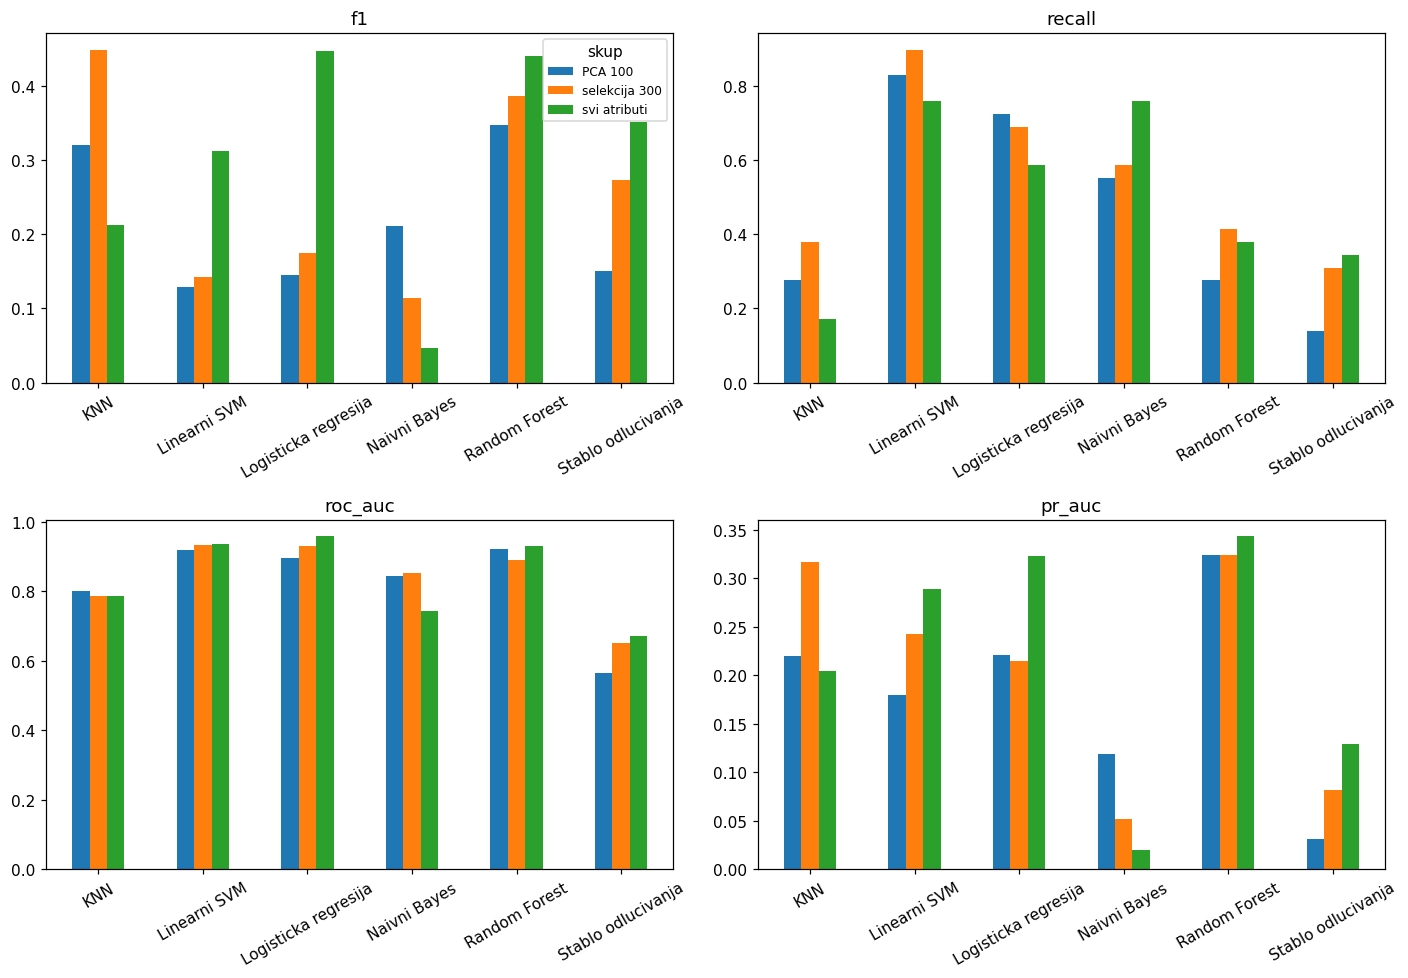

In [112]:
# Single-split comparison: F1, recall, ROC-AUC and PR-AUC per model and feature set.
metrics_to_plot = ["f1", "recall", "roc_auc", "pr_auc"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, metric in zip(axes.ravel(), metrics_to_plot):
    results_df.pivot(index="model", columns="skup", values=metric).plot(kind="bar", ax=ax, legend=False)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
axes.ravel()[0].legend(title="skup", fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()

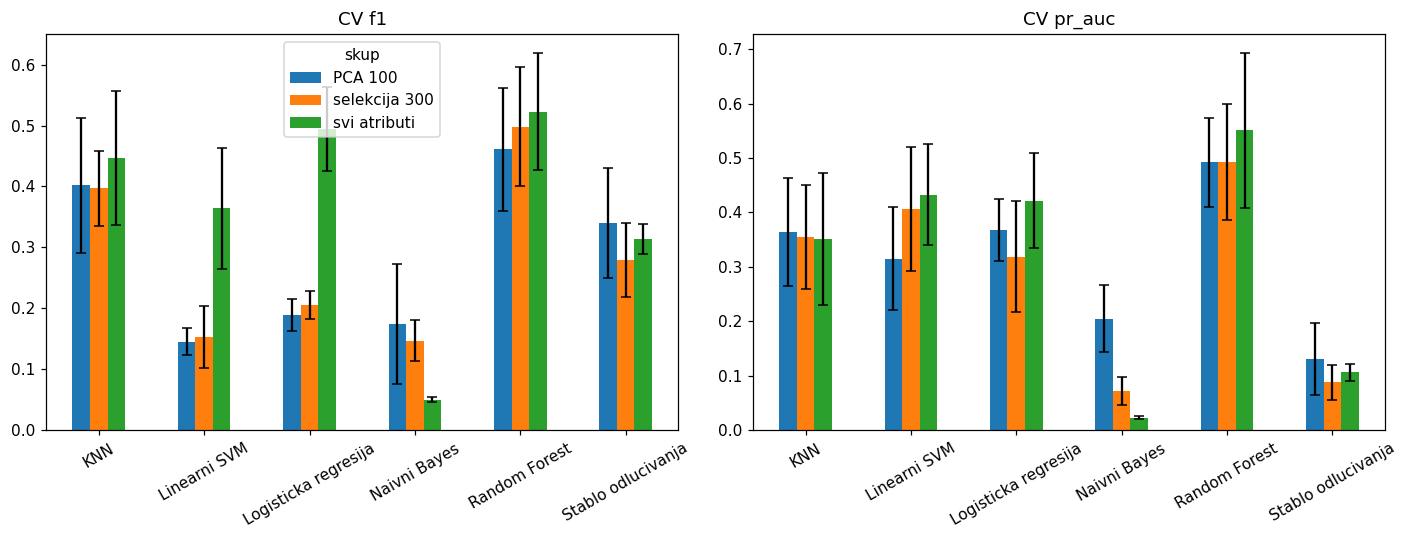

In [113]:
# Cross-validation comparison with error bars (mean +/- std over folds).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric in zip(axes, ["f1", "pr_auc"]):
    means = cv_full.pivot(index="model", columns="skup", values=metric + "_mean")
    stds = cv_full.pivot(index="model", columns="skup", values=metric + "_std")
    means.plot(kind="bar", ax=ax, yerr=stds, capsize=3, legend=(metric == "f1"))
    ax.set_title("CV " + metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIG_DIR / "cv_comparison.png", bbox_inches="tight")
plt.show()

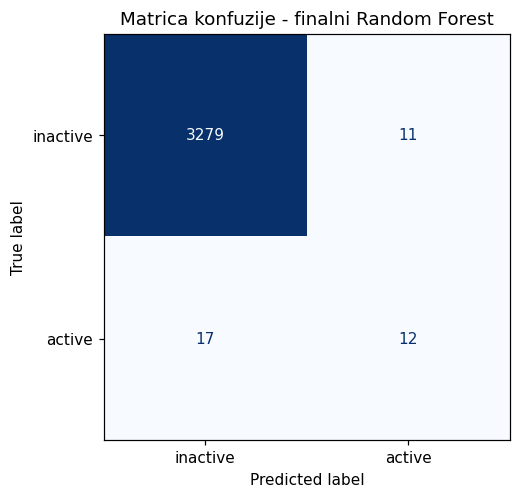

              precision    recall  f1-score   support

    inactive       0.99      1.00      1.00      3290
      active       0.52      0.41      0.46        29

    accuracy                           0.99      3319
   macro avg       0.76      0.71      0.73      3319
weighted avg       0.99      0.99      0.99      3319



In [114]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Final model: the tuned Random Forest on all attributes.
y_pred = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["inactive", "active"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Matrica konfuzije - finalni Random Forest")
plt.savefig(FIG_DIR / "confusion_matrix.png", bbox_inches="tight")
plt.show()

print(classification_report(y_test, y_pred, target_names=["inactive", "active"], zero_division=0))

### Zaključak

Random Forest se pokazao kao najbolji i najstabilniji model, naročito na svim atributima (najviši PR-AUC, i na jednoj podeli i u unakrsnoj validaciji). Logistička regresija ima najviši ROC-AUC, ali nižu preciznost. Redukcija atributa (PCA, selekcija) zadržava najveći deo kvaliteta uz mnogo manje dimenzija, dok Naivni Bayes i jedno stablo zaostaju.

Kao finalni model biramo podešeni Random Forest sa svim atributima. Matrica konfuzije pokazuje koliko retkih `active` slogova model zaista hvata i koliko lažnih uzbuna pravi, što je realna slika za ovako redak ishod.